# The shadow price expires

Every LP solver prints shadow prices, and everyone knows what they mean: the
marginal value of one more unit of a scarce resource. A wholesale bakery's three
binding resources price out at `$18.00` per oven-hour, `$11.00` per labor-hour and
`$6.00` per kilogram of flour. There is `$5,000` to spend on expansion. The
resource to buy is obvious.

It is obvious and it is wrong. Spending the budget on oven time — the highest
shadow price on the sheet — **loses `$3,476`**. Putting `$4,352` of it into
flour, the *lowest* of the three, makes `$4,702`, and the best mixed purchase of
the full budget makes `$7,187`. Ranked by the dollars they actually deliver, the three resources come
out in **exactly the reverse** of their shadow-price order.

Nothing here is a paradox and no number above is wrong. A shadow price is a
**derivative**, $\lambda_i = \partial f^\star/\partial b_i$, and a derivative
comes with a radius of validity that the number itself does not carry. Oven time
is worth `$18/hr` for the next **84.7 hours** and `$0.00/hr` after that, because
at 84.7 hours the cakes run out and there is nothing left to put in the oven.
Flour is worth `$6.00/kg` for 1,277 kg. The prices are identical in kind; the
*ranges* differ by a factor of fifteen, and the ranges are what the decision
turns on.

This notebook is about getting that range — and it is the part that is not
obvious. It comes out of the same held KKT factorization that produced the
price, by a ratio test, with **no re-solve**:

$$\alpha = \min_i \frac{\text{distance to } i\text{'s bound}}
{\left|\left(\partial x^\star/\partial b\right)_i\right|},$$

so *the current price and the distance to its expiry cost the same one solve*.
Each further step of the staircase costs exactly one more. Three complete
marginal-value schedules, over the whole `$5,000` of purchasable capacity, take
**11 solves** between them.

Along the way, three things that are easy to get wrong:

* **Resources are complements, so marginal values do not compose.** The best
  joint purchase buys 155.7 oven-hours — nearly *twice* past oven's own 84.7-hour
  expiry — because buying flour puts the cakes back and restores the oven price.
  Ranking resources one at a time beats ranking them by shadow price, and the
  joint solve beats that.
* **The range is a *primal* ratio test.** It reports a coordinate reaching a
  bound. It says nothing about an active row that *releases* — a multiplier
  falling to zero — and in section 8 that makes the reported range 21% too long.
  The information is in the same factorization, one column over.
* **An LP cannot tell you $\mathrm d\lambda/\mathrm db$**, and POUNCE refuses
  rather than guessing. A linear program has no curvature, so the reduced
  normalizer the activity classifier needs is zero and the regime cannot be
  measured. That refusal is the correct answer: for an LP $\mathrm
 d\lambda/\mathrm db$ is zero almost everywhere and undefined at the
  breakpoints — which is the staircase, and the staircase is what you should
  have asked for.

Notebook 39 puts an error bar on a shadow price, propagating uncertainty in the
*model parameters* $\theta$ into $\lambda$. This one holds the model exactly
right and asks a different question: over what range of the *right-hand side*
$b$ is $\lambda$ the number you should be multiplying by.

Everything runs against `pounce.sensitivity`, the pure-Python analysis layer, so
there is no modelling language in the way — every object below is a NumPy array
or a POUNCE call.

In [1]:
import platform, subprocess
import importlib.metadata as meta
import numpy as np
import matplotlib.pyplot as plt
import pounce
from pounce.sensitivity import (
    SensSession, NlBridge, solution_report, active_set_changes,
)

SOURCE_COMMIT = subprocess.run(
    ["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
print(f"python        {platform.python_version()}")
print(f"pounce-solver {meta.version('pounce-solver')}")
print(f"commit        {SOURCE_COMMIT[:12]}")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})

python        3.12.11
pounce-solver 0.11.0
commit        02de79ac6914


## 1. The bakery

Three products — croissants, loaves, cakes — each consuming three resources:
oven time, labor, and flour. Weekly capacities are fixed; the plan maximizes
contribution margin.

$$\max_{x\ge 0}\ c^{\mathsf T}x
\quad\text{subject to}\quad A x \le b,$$

with $x$ the weekly production of each product, $A$ the resource use per unit,
$b$ the weekly capacity, and $c$ the margin per unit.

The data are chosen so the base problem is **non-degenerate with all three rows
binding**, which is the interesting case and not the generic one. The
construction is backwards: pick $A$, pick the shadow prices $\lambda$ you want
the answer to have, pick a strictly positive production plan $x^\star$, then set

$$c = A^{\mathsf T}\lambda, \qquad b = A x^\star .$$

Complementary slackness and stationarity are then satisfied by construction at
$(x^\star,\lambda)$, so the solver must find that vertex, all three rows tight
and all three products made. This matters: every claim downstream is vacuous if
a row is slack or a product is zero, so section 1 ends by asserting it.

In [2]:
PROD = ["croissant", "loaf", "cake"]
RES  = ["oven", "labor", "flour"]
UNIT = ["hr", "hr", "kg"]

A = np.array([[0.030, 0.070, 0.350],     # oven-hr   per croissant / loaf / cake
              [0.020, 0.040, 0.500],     # labor-hr  per unit
              [0.090, 0.400, 0.900]])    # flour-kg  per unit

LAM0   = np.array([18.0, 11.0, 6.0])     # the shadow prices we design in
XS     = np.array([18000.0, 4000.0, 250.0])   # the production plan we design in
PROFIT = A.T @ LAM0                      # margin per unit  ($/croissant, ...)
B0     = A @ XS                          # weekly capacity

COST   = np.array([7.00, 8.00, 2.50])    # $ to buy one more hr / hr / kg
BUDGET = 5000.0

print(f"{'':11s}{'margin/unit':>13s}{'plan':>10s}")
for j, p in enumerate(PROD):
    print(f"{p:11s}{PROFIT[j]:13.2f}{XS[j]:10.0f}")
print()
print(f"{'':11s}{'capacity':>11s}{'':4s}{'buy at':>9s}{'budget buys':>14s}")
for i, r in enumerate(RES):
    print(f"{r:11s}{B0[i]:11.1f} {UNIT[i]:3s}{COST[i]:9.2f}"
          f"{BUDGET / COST[i]:11.1f} {UNIT[i]}")

             margin/unit      plan
croissant           1.30     18000
loaf                4.10      4000
cake               17.20       250

              capacity       buy at   budget buys
oven             907.5 hr      7.00      714.3 hr
labor            645.0 hr      8.00      625.0 hr
flour           3445.0 kg      2.50     2000.0 kg


### Capacities as parameters

`pounce.sensitivity` addresses a parameter by the **equality row that pins it**.
There is no `make_parameter` in the Python layer: you introduce the parameter as
a variable and pin it with an equality, and the row index of that equality is
the parameter's handle. So each capacity $b_i$ becomes a sixth, seventh, eighth
variable, pinned by

$$b_i^{\text{var}} = b_i^{0} \qquad(\text{rows } 0,1,2)$$

and the capacity constraint is written against the *variable*, not the constant:

$$\left(Ax\right)_i - b_i^{\text{var}} \le 0 \qquad(\text{rows } 3,4,5).$$

That is the whole trick. Differentiating with respect to the pin row's
right-hand side is differentiating with respect to the capacity, and the ratio
test that comes with it is a ratio test in capacity units.

`solve_for_sensitivity` would build this session in one call, but it discards
the solve's `info`, and we want `info["mult_g"]` for the prices. Its body is six
lines, so we inline them — which also shows the layer is not doing anything
magic. The one option that matters is `bound_relax_factor = 0.0`: POUNCE
relaxes bounds by a hair by default, and the activity accessors in section 6
refuse to classify a solve whose bounds were relaxed, because a coordinate can
then sit *outside* its bound and "on the bound" stops being a well-posed
question.

In [3]:
NAMES  = PROD + ["b_oven", "b_labor", "b_flour"]
ROWS   = ["pin_oven", "pin_labor", "pin_flour",
          "oven_cap", "labor_cap", "flour_cap"]
CAPROW = dict(zip(RES, ROWS[3:]))
PINROW = dict(zip(RES, range(3)))          # the pin row index == the handle


def build(b, quad=None):
    """The bakery LP (or its quadratic-revenue variant) at capacities `b`."""
    v = pounce.NlExpr.vars(6)
    cons = [v[3], v[4], v[5]]                                  # the three pins
    for i in range(3):
        cons.append(sum(A[i, j] * v[j] for j in range(3)) - v[3 + i])
    if quad is None:
        obj = -sum(PROFIT[j] * v[j] for j in range(3))
    else:
        a, k = quad
        obj = -sum(a[j] * v[j] - k[j] * v[j] * v[j] for j in range(3))
    return pounce.build_nl_problem(
        n=6, objective=obj, constraints=cons,
        g_l=list(b) + [-1e19] * 3,          # pins are equalities: g_l == g_u
        g_u=list(b) + [0.0, 0.0, 0.0],      # caps are  (Ax)_i - b_i <= 0
        x_l=[0.0, 0.0, 0.0, -1e19, -1e19, -1e19], x_u=[1e19] * 6,
        x0=list(XS) + list(b), var_names=NAMES, con_names=ROWS)


def solve(b, quad=None):
    """Solve at capacities `b`; return (SensSession, info).

    This is `solve_for_sensitivity` with its body spelled out, so that the
    solve's `info` -- which holds the multipliers -- survives.
    """
    nl = build(b, quad)
    prob = pounce.Problem(nl.n, nl.m, NlBridge(nl),
                          lb=nl.x_l, ub=nl.x_u, cl=nl.g_l, cu=nl.g_u)
    prob.add_option("bound_relax_factor", 0.0)   # required by the activity accessors
    prob.add_option("print_level", 0)
    solver = pounce.Solver(prob)
    x, info = solver.solve(np.asarray(nl.x0))
    sess = SensSession(nl, solver, NAMES, ROWS, pins=PINROW)
    sess.base_x, sess.base_obj = np.asarray(x, float), float(info["obj_val"])
    return sess, info


def prices(info):
    """The three capacity shadow prices, in $ per unit of capacity."""
    return np.asarray(info["mult_g"])[3:]


def profit(b, quad=None):
    return -float(solve(b, quad)[1]["obj_val"])

### Signs

`info["mult_g"]` holds multipliers in the **Lagrange** convention: for a row
written $g(x) \le h$ the multiplier is $\lambda \ge 0$, and it is the derivative
of the *minimized* objective with respect to $h$. Our objective is negative
profit, and the capacity row is $(Ax)_i - b_i \le 0$, so relaxing $b_i$ by one
unit relaxes that row's right-hand side by one unit and

$$\frac{\partial(\text{profit})}{\partial b_i} = \lambda_i \ge 0 .$$

The prices come out positive with no sign flip. (This is the negation of the
AMPL/Pyomo `dual` marginal for a minimize model, which is why notebook 39 writes
`-m.dual[m.cap]` and this one does not.)

In [4]:
sess0, info0 = solve(B0)
X0, P0, LAM = sess0.base_x[:3], profit(B0), prices(info0)
SLACK = B0 - A @ X0

print(f"status  {info0['status']}   weekly profit  ${P0:,.2f}\n")
print(f"{'':11s}{'make':>10s}")
for j, p in enumerate(PROD):
    print(f"{p:11s}{X0[j]:10.1f}")
print()
print(f"{'':11s}{'used':>10s}{'capacity':>11s}{'slack':>9s}{'shadow price':>15s}")
for i, r in enumerate(RES):
    print(f"{r:11s}{(A @ X0)[i]:10.1f}{B0[i]:11.1f}{SLACK[i]:9.4f}"
          f"{LAM[i]:11.2f} $/{UNIT[i]}")

# every claim below is vacuous without these
assert info0["status"] == 0
assert np.all(X0 > 1.0),          "a product hit zero -- not the intended vertex"
assert np.all(SLACK < 1e-6),      "a capacity row is slack -- its price is 0"
assert np.all(LAM > 1e-6),        "a shadow price vanished -- the row is weak"
assert np.allclose(LAM, LAM0) and np.allclose(X0, XS)
print("\nall three rows binding, all three products made, all three prices positive")

status  0   weekly profit  $44,100.00

                 make
croissant     18000.0
loaf           4000.0
cake            250.0

                 used   capacity    slack   shadow price
oven            907.5      907.5   0.0000      18.00 $/hr
labor           645.0      645.0   0.0000      11.00 $/hr
flour          3445.0     3445.0   0.0000       6.00 $/kg

all three rows binding, all three products made, all three prices positive


## 2. Three prices and the obvious plan

The sheet says oven time is worth `$18.00/hr` and costs `$7.00/hr` to buy — a
margin of `$11.00` on every hour. Labor nets `$3.00/hr`, flour `$3.50/kg`. All
three are worth buying; oven time is worth buying *most*, by a wide margin, and
it is where the `$5,000` should go.

That is the reasoning this notebook is about. Below it is carried out, and then
the resulting plan is priced by actually re-solving at the new capacity — the
only number that is not a prediction.

In [5]:
def net(buy):
    """Realized profit gain minus purchase cost, by a genuine re-solve."""
    buy = np.asarray(buy, float)
    return profit(B0 + buy) - P0 - float(COST @ buy)


print(f"{'':11s}{'shadow':>10s}{'cost':>8s}{'margin':>9s}"
      f"{'spend all $5,000':>19s}{'predicted':>12s}{'realized':>12s}")
naive_rank = np.argsort(-LAM)
for i in naive_rank:
    g = BUDGET / COST[i]
    buy = np.eye(3)[i] * g
    print(f"{RES[i]:11s}{LAM[i]:10.2f}{COST[i]:8.2f}{LAM[i] - COST[i]:9.2f}"
          f"{g:14.1f} {UNIT[i]:3s}{(LAM[i] - COST[i]) * g:12,.0f}"
          f"{net(buy):12,.2f}")

NAIVE = np.eye(3)[naive_rank[0]] * (BUDGET / COST[naive_rank[0]])
print(f"\nrank by shadow price:  {' > '.join(RES[i] for i in naive_rank)}")
print(f"the obvious plan (all {RES[naive_rank[0]]}) is predicted to make "
      f"${(LAM[naive_rank[0]] - COST[naive_rank[0]]) * BUDGET / COST[naive_rank[0]]:,.0f}"
      f" and makes ${net(NAIVE):+,.2f}")

               shadow    cost   margin   spend all $5,000   predicted    realized
oven            18.00    7.00    11.00         714.3 hr        7,857   -3,476.14
labor           11.00    8.00     3.00         625.0 hr        1,875   -1,168.57
flour            6.00    2.50     3.50        2000.0 kg        7,000    4,053.57

rank by shadow price:  oven > labor > flour
the obvious plan (all oven) is predicted to make $7,857 and makes $-3,476.14


The predicted column is $(\lambda_i - \text{cost}_i) \Delta_i$ — the shadow
price used the way shadow prices are used. Every entry in it is wrong, and the
worst error is on the resource the ranking picked. Buying `$5,000` of oven time
was supposed to make `$7,857` and instead **loses `$3,476`**.

The linearization is not subtly inaccurate here; it is qualitatively wrong. So
the question is not "how accurate is $\lambda$" but "over what range is
$\lambda$ *the right number at all*", and that is a question about where the
active set changes.

## 3. How far does the price hold?

$\lambda_i$ is exact for as long as the optimal basis is unchanged. Increase
$b_i$ and the solution moves along a ray $\partial x^\star/\partial b_i$ that
the KKT factorization already contains; the basis survives until some coordinate
of that ray reaches a bound. Finding the first one is a ratio test, and
`solution_report` runs it against the held factor.

Ask for a step of the full budget's worth of each resource and read back the
fraction of it that is actually valid:

* `alpha` — the fraction of the requested step that keeps the active set,
* `first` — which coordinate ends it,
* `first_kind` — whether that coordinate is a `"variable"` or a `"constraint"`.

No re-solve happens. This is the same factorization the base solve left behind.

In [6]:
print(f"{'':11s}{'price':>9s}{'holds for':>16s}{'':4s}{'ended by':>12s}{'':2s}{'kind':>10s}")
REACH, RANGE0 = {}, {}
for i, r in enumerate(RES):
    span = BUDGET / COST[i]                    # the whole budget, in resource units
    rep  = solution_report(sess0, [PINROW[r]], [span])
    hold = rep.alpha * span
    REACH[r], RANGE0[r] = span, hold
    print(f"{r:11s}{LAM[i]:6.2f} $/{UNIT[i]:2s}{hold:12.1f} {UNIT[i]:3s}"
          f"{'':4s}{str(rep.first):>12s}{'':2s}{str(rep.first_kind):>10s}")

print(f"\nthe budget would buy {REACH['oven']:.1f} oven-hr; the price survives "
      f"{RANGE0['oven'] / REACH['oven']:.1%} of that")
print(f"flour ranges {RANGE0['flour'] / RANGE0['oven']:.0f}x further than oven "
      f"at {LAM[2] / LAM[0]:.2f}x the price")

               price       holds for        ended by        kind
oven        18.00 $/hr        84.7 hr             cake    variable
labor       11.00 $/hr       348.3 hr        croissant    variable
flour        6.00 $/kg      1277.1 kg        croissant    variable

the budget would buy 714.3 oven-hr; the price survives 11.9% of that
flour ranges 15x further than oven at 0.33x the price


Each range is ended by a **product hitting zero**. Buy oven time and the plan
shifts toward cakes, which are oven-hungry; 84.7 hours in, the recipe that was
absorbing the extra oven time has been pushed out of the plan entirely and the
remaining products cannot use another oven-hour at any price. That is the whole
mechanism, and it is why the range is a property of $A$ and $x^\star$ — not of
$\lambda$. Nothing about "`$18.00`" tells you it expires in 84.7 hours.

These come from one factorization and no re-solves, so they need checking
against the real thing. Re-solve on a grid and find where each price actually
changes:

In [7]:
print(f"{'':11s}{'ratio test':>13s}{'re-solved':>13s}{'agree to':>11s}")
for i, r in enumerate(RES):
    lo, hi = 0.0, REACH[r]                      # bisect on "is the price unchanged"
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if abs(prices(solve(B0 + np.eye(3)[i] * mid)[1])[i] - LAM[i]) < 1e-6:
            lo = mid
        else:
            hi = mid
    rel = abs(lo - RANGE0[r]) / RANGE0[r]
    print(f"{r:11s}{RANGE0[r]:9.2f} {UNIT[i]:3s}{lo:9.2f} {UNIT[i]:3s}{rel:11.1e}")
    assert rel < 1e-4, f"{r}: the ratio test disagrees with the re-solve"
print("\nthe ranges the held factor reported are the ranges the solver has")

              ratio test    re-solved   agree to
oven           84.66 hr     84.66 hr     2.8e-05


labor         348.31 hr    348.31 hr     6.7e-06
flour        1277.14 kg   1277.14 kg     2.0e-06

the ranges the held factor reported are the ranges the solver has


## 4. The marginal value schedule

A range is not yet a decision. Oven time is worth `$18.00/hr` for 84.7 hours —
but what is the 85th hour worth? The ratio test cannot say: past the breakpoint
the basis is different, and the held factor is a factorization of the *old* one.
Getting the next price costs one solve.

That is the honest shape of the cost, and it is a good bargain. Walking a
resource's whole schedule means: solve, read the price and the range from that
one factorization, jump to the end of the range, solve again. **One solve per
segment**, not one per grid point.

Two details in the loop below. The step past a breakpoint is nudged by a hair
($10^{-6}$ relative) so the next solve lands strictly inside the new segment
rather than on the knife edge. And a price that comes back below `$0.001` is
snapped to zero: once a resource is genuinely worthless the interior-point
solve leaves barrier residue of order $10^{-5}$ where exact arithmetic has a
flat zero, and printing `$0.00008/hr` would be reporting noise as a price.

In [8]:
def schedule(i, reach, max_seg=8):
    """The marginal value schedule for resource i, breakpoint to breakpoint."""
    segs, d, solves = [], 0.0, 0
    while d < reach - 1e-9 and len(segs) < max_seg:
        sess, info = solve(B0 + np.eye(3)[i] * d)      # one solve per segment
        solves += 1
        lam = float(prices(info)[i])
        if abs(lam) < 1e-3:
            lam = 0.0                                  # barrier residue at a dead row
        span = reach - d
        rep = solution_report(sess, [PINROW[RES[i]]], [span])   # no re-solve
        end = d + min(rep.alpha, 1.0) * span
        segs.append(dict(lo=d, hi=end, lam=lam,
                         first=rep.first, kind=rep.first_kind))
        if rep.alpha >= 1.0 - 1e-12:
            break
        d = end + 1e-6 * max(1.0, end)
    merged = [segs[0]]                       # a basis change need not move the price
    for s in segs[1:]:
        if abs(s["lam"] - merged[-1]["lam"]) < 1e-3:
            merged[-1] = {**merged[-1], "hi": s["hi"],
                          "first": s["first"], "kind": s["kind"]}
        else:
            merged.append(s)
    return merged, solves

In [9]:
SCHED, TOTAL_SOLVES = {}, 0
for i, r in enumerate(RES):
    segs, ns = schedule(i, REACH[r])
    SCHED[r], TOTAL_SOLVES = segs, TOTAL_SOLVES + ns
    print(f"{r}  --  {ns} solves for the whole schedule, "
          f"0 to {REACH[r]:,.0f} {UNIT[i]}")
    for s in segs:
        verdict = "BUY " if s["lam"] > COST[i] else "stop"
        print(f"    {s['lo']:8.1f} -> {s['hi']:8.1f} {UNIT[i]:3s}"
              f"{s['lam']:8.2f} $/{UNIT[i]:3s} {verdict}"
              f"   ends: {s['first']} ({s['kind']})")
    print()
print(f"{TOTAL_SOLVES} solves for all three complete schedules")

oven  --  3 solves for the whole schedule, 0 to 714 hr
         0.0 ->     84.7 hr    18.00 $/hr  BUY    ends: cake (variable)
        84.7 ->    714.3 hr     0.00 $/hr  stop   ends: None (None)

labor  --  3 solves for the whole schedule, 0 to 625 hr
         0.0 ->    348.3 hr    11.00 $/hr  BUY    ends: croissant (variable)
       348.3 ->    625.0 hr     0.00 $/hr  stop   ends: None (None)

flour  --  5 solves for the whole schedule, 0 to 2,000 kg
         0.0 ->   1277.1 kg     6.00 $/kg  BUY    ends: croissant (variable)
      1277.1 ->   1740.7 kg     3.00 $/kg  BUY    ends: cake (variable)
      1740.7 ->   2000.0 kg     0.00 $/kg  stop   ends: None (None)

11 solves for all three complete schedules


Oven and labor fall off a **cliff**: `$18.00` to `$0.00`, `$11.00` to `$0.00`, one
step. Flour descends a **staircase** — `$6.00`, then `$3.00` for another 464 kg,
then nothing. The shapes are different and neither is visible in the base
solve's output.

A schedule assembled from 11 solves is worth verifying against many. Re-solve on
a 120-point grid per resource and compare, skipping points within 0.3% of a
breakpoint, where the two sides of a discontinuity are both defensible:

In [10]:
def scheduled_price(segs, g):
    for s in segs:
        if s["lo"] - 1e-9 <= g <= s["hi"] + 1e-9:
            return s["lam"]
    return segs[-1]["lam"]


for i, r in enumerate(RES):
    grid, bad, tested = np.linspace(0.0, REACH[r], 120), 0, 0
    for g in grid:
        if min(min(abs(g - s["lo"]), abs(g - s["hi"])) for s in SCHED[r]) < 3e-3 * REACH[r]:
            continue
        tested += 1
        actual = float(prices(solve(B0 + np.eye(3)[i] * g)[1])[i])
        if abs(actual - scheduled_price(SCHED[r], g)) > 1e-3:
            bad += 1
    print(f"{r:11s}{bad:3d} of {tested:3d} grid prices disagree with the schedule")
    assert bad == 0

oven         0 of 117 grid prices disagree with the schedule


labor        0 of 117 grid prices disagree with the schedule


flour        0 of 117 grid prices disagree with the schedule


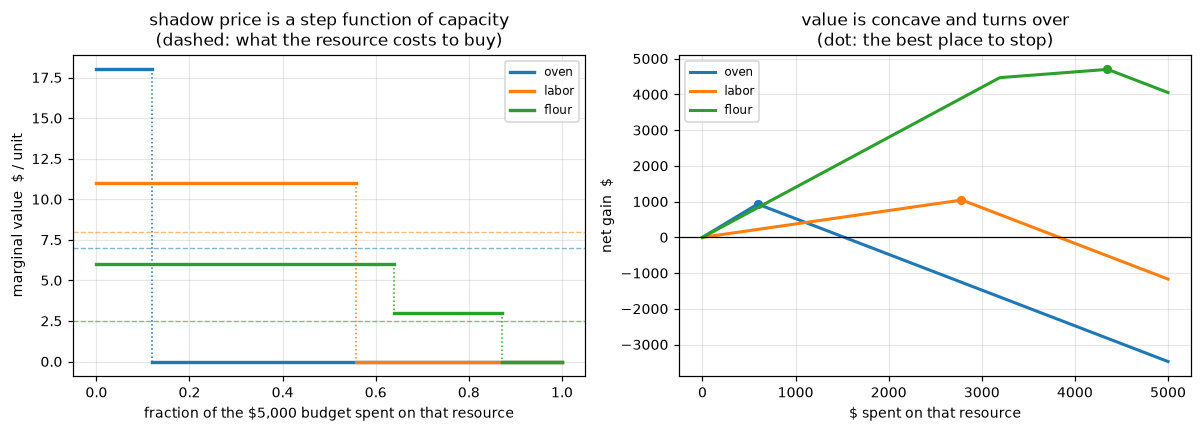

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

for i, r in enumerate(RES):
    col = f"C{i}"
    for k, s in enumerate(SCHED[r]):
        axes[0].plot([s["lo"] / REACH[r], s["hi"] / REACH[r]], [s["lam"]] * 2,
                     color=col, lw=2.2, label=r if k == 0 else None)
        if k:                                       # the jump down
            axes[0].plot([s["lo"] / REACH[r]] * 2,
                         [SCHED[r][k - 1]["lam"], s["lam"]],
                         color=col, lw=1.0, ls=":")
    axes[0].axhline(COST[i], color=col, lw=0.9, ls="--", alpha=0.55)

axes[0].set_xlabel("fraction of the $5,000 budget spent on that resource")
axes[0].set_ylabel("marginal value  $ / unit")
axes[0].set_title("shadow price is a step function of capacity\n"
                  "(dashed: what the resource costs to buy)")
axes[0].legend(fontsize=8)

for i, r in enumerate(RES):
    gs = np.linspace(0.0, REACH[r], 260)
    val = np.array([sum(max(0.0, min(g, s["hi"]) - s["lo"]) * s["lam"]
                        for s in SCHED[r]) for g in gs])
    spend = COST[i] * gs
    axes[1].plot(spend, val - spend, color=f"C{i}", lw=2.0, label=r)
    k = int(np.argmax(val - spend))
    axes[1].plot(spend[k], (val - spend)[k], "o", color=f"C{i}", ms=5)

axes[1].axhline(0.0, color="k", lw=0.8)
axes[1].set_xlabel("$ spent on that resource")
axes[1].set_ylabel("net gain  $")
axes[1].set_title("value is concave and turns over\n"
                  "(dot: the best place to stop)")
axes[1].legend(fontsize=8)
fig.tight_layout()

The left panel is the whole argument in one picture. Oven time starts at the top
and is the **first** curve to hit the floor — it is expensive precisely because
it is scarce, and it is scarce precisely because it runs out fast. Flour starts
lowest and is still above its purchase cost when the other two are worthless.

The right panel converts that into money. Each curve is
$V_i(\Delta) - \text{cost}_i\Delta$, the integral of the staircase minus what it
cost, and each is **concave and turns over**: past the dot you are buying a
resource whose marginal value has fallen below its price. The naive plan runs
the oven curve all the way to `$5,000`, far off the right of its turnover, which
is exactly the `$3,476` loss.

Note that the ordering by peak height is flour, then labor, then oven — the
reverse of the ordering by starting height.

## 5. The ranking flips

The schedule says where to stop: buy segments while the marginal value exceeds
the purchase cost, and stop at the end of the last one that does. That is an
exact answer for a single resource, because the staircase is exact.

Three plans, all priced by re-solving:

1. **Naive** — the whole `$5,000` into the highest shadow price.
2. **Staircase-informed** — the best *single* resource, bought to its own
   turnover point and no further.
3. **Joint** — spend the `$5,000` across all three optimally.

In [12]:
def stop_point(r, i):
    """Buy segments while the marginal value beats the price; stop there."""
    g = 0.0
    for s in SCHED[r]:
        if s["lam"] <= COST[i]:
            break
        g = s["hi"]
    return g


print(f"{'':11s}{'buy':>16s}{'spend':>12s}{'net':>13s}")
SINGLE = {}
for i, r in enumerate(RES):
    g = stop_point(r, i)
    buy = np.eye(3)[i] * g
    SINGLE[r] = (g, net(buy))
    print(f"{r:11s}{g:12.1f} {UNIT[i]:3s}{COST[i] * g:12,.2f}{SINGLE[r][1]:+13,.2f}")

best = max(RES, key=lambda r: SINGLE[r][1])
realized_rank = sorted(RES, key=lambda r: -SINGLE[r][1])
print(f"\nrank by shadow price :  {' > '.join(RES[i] for i in naive_rank)}")
print(f"rank by realized cash:  {' > '.join(realized_rank)}")
assert realized_rank == [RES[i] for i in naive_rank][::-1]
print("\n-- exactly reversed --")

                        buy       spend          net
oven               84.7 hr       592.61      +931.25
labor             348.3 hr     2,786.49    +1,044.94
flour            1740.7 kg     4,351.79    +4,701.79

rank by shadow price :  oven > labor > flour
rank by realized cash:  flour > labor > oven

-- exactly reversed --


Buying the *cheapest-priced* resource, and stopping where its own schedule says
to, makes **`$4,702`** on `$4,352` spent. Buying the dearest-priced one to the
hilt loses `$3,476`. Same budget, same model, same solver; a `$8,178` swing that
turns entirely on a number the base solve never printed.

Note also that all three single-resource plans are *profitable* when stopped
correctly. The `$3,476` loss is not the ranking's fault alone — it is the ranking
plus the assumption that a marginal value stays marginal for `$5,000` worth of
purchasing.

### The wrinkle: values do not compose

It is tempting to stop here with "rank by the staircase, not by the price". That
is better, and it is still not right, because the three staircases were each
computed with the other two capacities held fixed. Resources are
**complements**: the reason oven time expires at 84.7 hours is that the cakes
run out, and the reason the cakes run out is that they need *flour*. Buy flour
and the oven's own schedule changes.

The joint problem is one LP — the purchase vector $u$ enters as a variable and
the inner production problem stays linear, so the two collapse into a single
program:

$$\max_{x,u\ \ge\ 0}\ c^{\mathsf T}x - \text{cost}^{\mathsf T}u
\quad\text{s.t.}\quad Ax - u \le b^0,\quad \text{cost}^{\mathsf T}u \le 5000 .$$

In [13]:
def joint_plan(budget):
    v = pounce.NlExpr.vars(6)                     # v[:3] production, v[3:] purchases
    cons = [sum(A[i, j] * v[j] for j in range(3)) - v[3 + i] for i in range(3)]
    cons.append(sum(COST[i] * v[3 + i] for i in range(3)))
    nl = pounce.build_nl_problem(
        n=6, constraints=cons,
        objective=-(sum(PROFIT[j] * v[j] for j in range(3))
                    - sum(COST[i] * v[3 + i] for i in range(3))),
        g_l=[-1e19] * 4, g_u=list(B0) + [budget],
        x_l=[0.0] * 6, x_u=[1e19] * 6, x0=list(XS) + [0.0] * 3)
    prob = pounce.Problem(nl.n, nl.m, NlBridge(nl),
                          lb=nl.x_l, ub=nl.x_u, cl=nl.g_l, cu=nl.g_u)
    prob.add_option("print_level", 0)
    x, _ = pounce.Solver(prob).solve(np.asarray(nl.x0))
    return np.maximum(np.asarray(x)[3:], 0.0)


U = joint_plan(BUDGET)
print(f"{'':11s}{'joint buys':>16s}{'own turnover':>17s}")
for i, r in enumerate(RES):
    print(f"{r:11s}{U[i]:12.1f} {UNIT[i]:3s}{SINGLE[r][0]:13.1f} {UNIT[i]:3s}")
print(f"\nspend ${COST @ U:,.2f} of ${BUDGET:,.0f}   net ${net(U):+,.2f}")
print(f"vs the best single resource ({best}): ${SINGLE[best][1]:+,.2f}")
print(f"vs the naive plan:                 ${net(NAIVE):+,.2f}")


# oven expired at 84.7 hr with flour held fixed -- so buy some flour and re-ask
print(f"\n{'flour held at':>18s}{'oven price':>13s}{'holds for':>14s}{'':3s}{'ended by':>10s}")
for extra in [0.0, 500.0, 1000.0]:
    se, inf = solve(B0 + np.array([0.0, 0.0, extra]))
    rep = solution_report(se, [PINROW["oven"]], [REACH["oven"]])
    print(f"{B0[2] + extra:14,.0f} kg{prices(inf)[0]:11.2f} $/hr"
          f"{rep.alpha * REACH['oven']:11.1f} hr{'':3s}{str(rep.first):>10s}")

                 joint buys     own turnover
oven              155.7 hr          84.7 hr 
labor               0.0 hr         348.3 hr 
flour            1563.9 kg        1740.7 kg 

spend $5,000.00 of $5,000   net $+7,186.90
vs the best single resource (flour): $+4,701.79
vs the naive plan:                 $-3,476.14

     flour held at   oven price     holds for     ended by
         3,445 kg      18.00 $/hr       84.7 hr         cake
         3,945 kg      18.00 $/hr      107.4 hr         cake
         4,445 kg      18.00 $/hr      130.1 hr         cake


The joint plan buys **155.7 oven-hours** — nearly twice past oven's own
84.7-hour turnover, where its marginal value was measured as `$0.00`. Nothing was
wrong with that measurement, and the last table above says why. Oven time
expires at 84.7 hours *given 3,445 kg of flour*. Hold 500 kg more and the same
`$18.00` price runs to 107 hours; hold 1,000 kg more and it runs to 130. The
expiry date is not a property of the oven row — it is a property of the oven row
**and every other capacity in the model**, because what ends it is the cake
recipe running out, and cakes are made of flour.

This is the limit of what a one-resource-at-a-time analysis can tell you, and it
is worth being explicit about, because the staircase is so much better than the
shadow price that it invites over-trust. A marginal value is a partial
derivative; a budget allocation is a question about all of them at once; and
each staircase was walked with the other two capacities pinned at their original
values. The staircase told us the price expires and roughly where, which is what
made `$4,702` available instead of $-$`$3,476`. Closing the last `$2,485` took the
joint solve.

(A caution for anyone reproducing this: the joint optimum sits on a **degenerate
vertex** — cake is driven to within 0.1 unit of zero — so the dual there is not
unique and the price vector you read at that point depends on which optimal
basis the solver lands on. That is why the argument above is made with validity
ranges at non-degenerate points rather than with prices read off the joint
solution.)

## 6. Prices are not exogenous either

The staircase is a consequence of linearity. A linear program's value function is
piecewise linear, so its derivative is piecewise *constant*: the price does not
decay, it holds flat and then falls off a cliff. Real markets are not like that,
and the cliff is an artifact worth removing — partly because it is unrealistic,
and mostly because removing it changes what the sensitivity layer can tell you.

Let the unit margin fall as output rises,

$$m_j(x_j) = c_j\left[1 + \tau\left(1 - x_j/x_j^\star\right)\right],$$

so $\tau$ is the fraction of the unit margin lost when output **doubles**. We
take $\tau = 0.10$: a modest, entirely ordinary amount of price pressure.
Integrating gives a concave quadratic objective, and choosing the intercepts to
match $m_j(x_j^\star) = c_j$ means the new model reproduces the LP's optimal
plan *and* all three shadow prices exactly. Nothing about the answer changes.
What changes is that the prices now decay smoothly, and

$$\frac{\mathrm d\lambda_i}{\mathrm d b_i}$$

becomes a finite number that the held factorization can hand over.

In [14]:
TAU = 0.10
KQ   = TAU * PROFIT / (2.0 * XS)         # curvature of the revenue in each product
AQ   = PROFIT * (1.0 + TAU)              # intercept, chosen so m(x*) == PROFIT
QUAD = (AQ, KQ)

sessq, infoq = solve(B0, quad=QUAD)
XQ, LAMQ = sessq.base_x[:3], prices(infoq)

print(f"{'':11s}{'LP plan':>10s}{'quad plan':>11s}{'':4s}"
      f"{'LP price':>10s}{'quad price':>12s}")
for i in range(3):
    print(f"{PROD[i]:11s}{X0[i]:10.1f}{XQ[i]:11.1f}{'':4s}"
          f"{LAM[i]:10.2f}{LAMQ[i]:12.2f}")
assert np.allclose(XQ, X0, rtol=1e-6) and np.allclose(LAMQ, LAM, rtol=1e-6)
print("\nsame plan, same three prices -- only the curvature is new")

              LP plan  quad plan      LP price  quad price
croissant     18000.0    18000.0         18.00       18.00
loaf           4000.0     4000.0         11.00       11.00
cake            250.0      250.0          6.00        6.00

same plan, same three prices -- only the curvature is new


### Asking for $\mathrm d\lambda/\mathrm db$

`SensSession.column(pin_idx)` returns the derivative of the **whole KKT
solution** with respect to that pin's right-hand side — primal variables and
multipliers together — as one back-solve against the held factor.
`SensSession.mult_entry(row_name)` gives the index at which a particular row's
multiplier lives in that vector. Together:

```python
dlam_db = sess.column(PINROW["oven"])[sess.mult_entry("oven_cap")]
```

`mult_entry` **gates on activity** (gh#910). An equality always has a
$\mathrm d\lambda/\mathrm dp$ row. An inequality has one only where it is
*strictly* active at the solved point, and the gate reads `reduced_row_activity`
rather than the cheap classifier. The reason is not bureaucratic: an inactive
row's multiplier is zero over a whole neighbourhood, so its derivative is a
structural zero the factor does not carry, and a weakly active row — slack and
multiplier both vanishing — has two one-sided derivatives that disagree and no
two-sided value at all. Here all three capacity rows are strictly active, so all
three answer. Section 8 is what happens when they do not.

In [15]:
print("row activity (the gate mult_entry reads):")
for r in RES:
    j = ROWS.index(CAPROW[r])
    st = sessq.solver.reduced_row_activity([j])
    print(f"    {CAPROW[r]:11s}{st['status'][0]:>18s}"
          f"   reduced curvature {st['q_reduced'][0]:11.3e}")

print(f"\n{'':11s}{'price':>10s}{'dlam/db':>12s}{'central FD':>13s}{'rel err':>10s}")
DLAM = {}
for i, r in enumerate(RES):
    dl = float(sessq.column(PINROW[r])[sessq.mult_entry(CAPROW[r])])
    h = 1e-4 * B0[i]
    fd = (prices(solve(B0 + np.eye(3)[i] * h, quad=QUAD)[1])[i]
          - prices(solve(B0 - np.eye(3)[i] * h, quad=QUAD)[1])[i]) / (2 * h)
    rel = abs(dl - fd) / abs(fd)
    DLAM[r] = dl
    print(f"{r:11s}{LAMQ[i]:10.2f}{dl:12.6f}{fd:13.6f}{rel:10.1e}")
    assert rel < 1e-4, f"{r}: dlam/db disagrees with a finite difference"

row activity (the gate mult_entry reads):
    oven_cap      strongly_active   reduced curvature   2.044e-01
    labor_cap     strongly_active   reduced curvature   1.514e-01
    flour_cap     strongly_active   reduced curvature   8.923e-03

                price     dlam/db   central FD   rel err
oven            18.00   -0.181149    -0.181149   2.1e-10
labor           11.00   -0.120908    -0.120908   3.9e-10
flour            6.00   -0.004513    -0.004513   8.2e-10


## 7. The second-order value model

With $\mathrm d\lambda/\mathrm db$ in hand the value of buying $\Delta$ more of
resource $i$ has a closed form,

$$V_i(\Delta) = \lambda_i\Delta + \tfrac12
\frac{\mathrm d\lambda_i}{\mathrm d b_i} \Delta^2 ,$$

and for a quadratic objective under linear constraints this is not an
approximation at all — the value function *is* exactly quadratic, for as long as
the active set holds. The first-order term alone is the naive prediction from
section 2; the second term is the expiry, written as a rate rather than a
cliff.

Two numbers follow immediately, with no further solves:

* the **half-life** $\lambda_i / \bigl(2 |\mathrm d\lambda_i/\mathrm db_i|\bigr)$,
  where the price has fallen by half;
* the **turnover** $(\lambda_i - \text{cost}_i)/|\mathrm d\lambda_i/\mathrm db_i|$,
  where it drops below what the resource costs and buying should stop.

In [16]:
print(f"{'':11s}{'price':>9s}{'dlam/db':>12s}{'half-life':>15s}"
      f"{'buy until':>15s}{'spend':>12s}")
STOPQ = {}
for i, r in enumerate(RES):
    s = DLAM[r]
    half = LAMQ[i] / (2.0 * abs(s))
    turn = (LAMQ[i] - COST[i]) / abs(s)
    STOPQ[r] = turn
    print(f"{r:11s}{LAMQ[i]:9.2f}{s:12.6f}{half:11.1f} {UNIT[i]:3s}"
          f"{turn:11.1f} {UNIT[i]:3s}{COST[i] * turn:12,.2f}")

spend = sum(COST[i] * STOPQ[r] for i, r in enumerate(RES))
print(f"\ntotal worth spending: ${spend:,.2f} of the ${BUDGET:,.0f} available")
print(f"the smooth model says leave ${BUDGET - spend:,.2f} unspent")

               price     dlam/db      half-life      buy until       spend
oven           18.00   -0.181149       49.7 hr        60.7 hr       425.07
labor          11.00   -0.120908       45.5 hr        24.8 hr       198.50
flour           6.00   -0.004513      664.7 kg       775.5 kg     1,938.67

total worth spending: $2,562.23 of the $5,000 available
the smooth model says leave $2,437.77 unspent


In [17]:
i, r = 2, "flour"
print(f"{'':10s}{'re-solve':>13s}{'quadratic model':>18s}{'rel err':>11s}")
for d in [50.0, 200.0, 500.0, 775.0, 1000.0, 1100.0, 1200.0, 1277.0]:
    V = profit(B0 + np.eye(3)[i] * d, quad=QUAD) - profit(B0, quad=QUAD)
    model = LAMQ[i] * d + 0.5 * DLAM[r] * d * d
    flag = "" if abs(V - model) / abs(V) < 1e-6 else "   <-- departs"
    print(f"{d:8.0f} kg{V:13,.2f}{model:18,.2f}{abs(V - model) / abs(V):11.1e}{flag}")

               re-solve   quadratic model    rel err
      50 kg       294.36            294.36    1.5e-11
     200 kg     1,109.73          1,109.73    6.6e-11
     500 kg     2,435.82          2,435.82    1.9e-10
     775 kg     3,294.57          3,294.57    3.3e-10
    1000 kg     3,743.30          3,743.30    4.9e-10
    1100 kg     3,870.43          3,869.39    2.7e-04   <-- departs
    1200 kg     3,960.24          3,950.35    2.5e-03   <-- departs
    1277 kg     4,004.80          3,981.93    5.7e-03   <-- departs


Exact to ten digits out to 1,000 kg, and then it starts to drift. That drift is
the subject of section 8, and it is not a failure of the quadratic model — the
value function really is quadratic while the active set holds, so a departure
means the active set stopped holding.

First, the picture the two models make together:

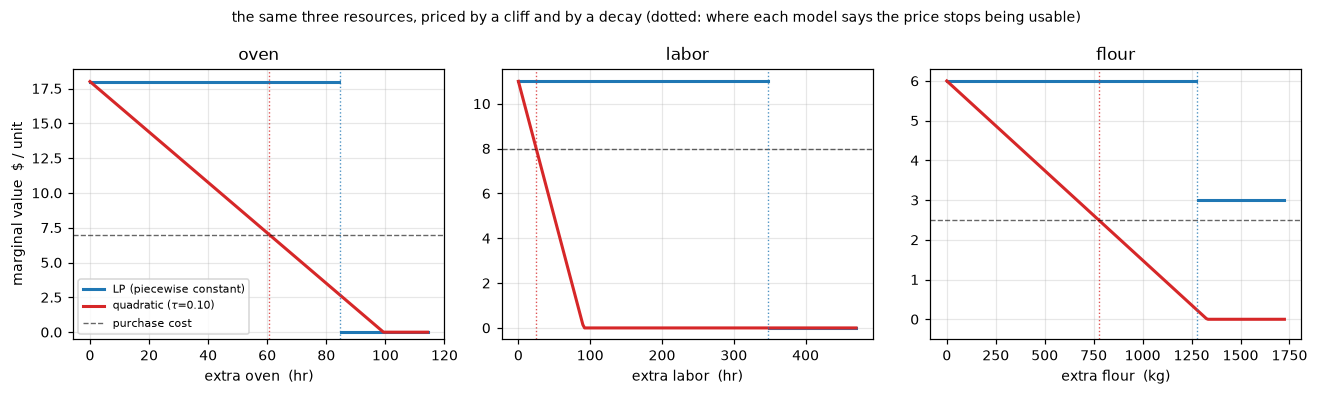

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=False)

for i, (r, ax) in enumerate(zip(RES, axes)):
    top = min(REACH[r], 1.35 * max(RANGE0[r], STOPQ[r]))
    gs = np.linspace(0.0, top, 200)

    for k, s in enumerate(SCHED[r]):                       # the LP staircase
        seg = gs[(gs >= s["lo"]) & (gs <= s["hi"])]
        if seg.size:
            ax.plot(seg, np.full_like(seg, s["lam"]), color="C0", lw=2.0,
                    label="LP (piecewise constant)" if k == 0 else None)

    ax.plot(gs, np.maximum(LAMQ[i] + DLAM[r] * gs, 0.0),      # the smooth decay
            color="C3", lw=2.0, label=r"quadratic ($\tau$=0.10)")
    ax.axhline(COST[i], color="k", lw=0.9, ls="--", alpha=0.6,
               label="purchase cost")
    ax.axvline(RANGE0[r], color="C0", lw=0.9, ls=":", alpha=0.8)
    ax.axvline(STOPQ[r], color="C3", lw=0.9, ls=":", alpha=0.8)
    ax.set_ylim(bottom=-0.5)
    ax.set_xlabel(f"extra {r}  ({UNIT[i]})")
    ax.set_title(r)
    if i == 0:
        ax.set_ylabel("marginal value  $ / unit")
        ax.legend(fontsize=7, loc="lower left")

fig.suptitle("the same three resources, priced by a cliff and by a decay "
             "(dotted: where each model says the price stops being usable)",
             fontsize=9)
fig.tight_layout()

The two models disagree about the *shape* of the decay. It is worth asking
whether they agree about the thing the decision turns on — how much of the
budget each price is good for. Ranges in hours and kilograms are not comparable;
ranges in dollars are:

In [19]:
print(f"{'':11s}{'price':>9s}{'LP: usable':>21s}{'quadratic: usable':>25s}")
for i, r in enumerate(RES):
    lp_spend, q_spend = COST[i] * SINGLE[r][0], COST[i] * STOPQ[r]
    print(f"{r:11s}{LAM[i]:9.2f}{lp_spend:14,.0f} ({lp_spend / BUDGET:5.1%})"
          f"{q_spend:16,.0f} ({q_spend / BUDGET:5.1%})")

               price           LP: usable        quadratic: usable
oven           18.00           593 (11.9%)             425 ( 8.5%)
labor          11.00         2,786 (55.7%)             198 ( 4.0%)
flour           6.00         4,352 (87.0%)           1,939 (38.8%)


Under the LP the ordering is **exactly inverse to the shadow price**: the
dearest resource is good for 12% of the budget, the middle one for 56%, the
cheapest for 87%. The smooth model agrees at the extremes — flour is still far
and away the longest-lived, oven time still short — but it puts labor, the
middle price, shortest of the three. So the tendency is real and it is a
*tendency*, not a law.

The mechanism behind it is not specific to this bakery. A large multiplier means
a tightly binding row, which means small movements of $b$ reshuffle the plan
quickly, which is the condition for the price to move. **A high shadow price is
evidence that the price is about to change.** Ranking candidates by marginal
value, without the range, is biased toward exactly the ones whose marginal value
you should trust least.

The practical difference between the two models is what you have to compute.
Under the LP you get a range for free and every subsequent step costs a solve.
Under the quadratic you get a *rate* for free, and the whole decay curve with it
— one back-solve, no staircase to walk.

## 8. Where the range stops — and what it does not cover

Ask the quadratic model the section 3 question: how far does the flour price
hold?

In [20]:
repq = solution_report(sessq, [PINROW["flour"]], [REACH["flour"]])
print(f"solution_report : holds for {repq.alpha * REACH['flour']:.1f} kg"
      f"   ended by {repq.first} ({repq.first_kind})")
print(f"active_set_changes over +1,200 kg: "
      f"{active_set_changes(sessq, [PINROW['flour']], [1200.0])}")
print(f"\nbut the quadratic value model departed at about 1,050 kg.")

solution_report : holds for 1277.1 kg   ended by croissant (variable)
active_set_changes over +1,200 kg: []

but the quadratic value model departed at about 1,050 kg.


Both accessors say the active set survives to 1,277 kg, and the value model says
it does not survive past about 1,050. One of them is wrong, and it is not the
value model.

The ratio test behind `alpha` is **primal**. It predicts the step
$\partial x^\star/\partial b$, propagates it to the rows, and asks which
coordinate reaches a bound first — a variable hitting zero, or a slack row
becoming tight. It is a complete answer to that question. But an active set has
two ways to change, and the other one is a row that **releases**: an active
constraint whose multiplier falls to zero and lets go. No coordinate reaches a
bound when that happens. Nothing in a primal ratio test can see it, and
`active_set_changes` records segments over the factor's $x$ block, so it
does not report a constraint row leaving either.

Watch the multipliers instead:

In [21]:
print(f"{'flour +':>9s}{'oven':>10s}{'labor':>10s}{'flour':>10s}{'labor slack':>14s}")
for d in [0.0, 400.0, 800.0, 1000.0, 1060.0, 1100.0, 1277.0]:
    se, inf = solve(B0 + np.eye(3)[2] * d, quad=QUAD)
    lam = prices(inf)
    slack = (B0 + np.eye(3)[2] * d - A @ se.base_x[:3])[1]
    print(f"{d:7.0f} kg" + "".join(f"{v:10.3f}" for v in lam) + f"{slack:14.3f}")

  flour +      oven     labor     flour   labor slack
      0 kg    18.000    11.000     6.000         0.000
    400 kg    27.561     6.818     4.195         0.000
    800 kg    37.123     2.636     2.389         0.000
   1000 kg    41.903     0.545     1.487         0.000
   1060 kg    43.253     0.000     1.223         0.682
   1100 kg    43.778     0.000     1.079         4.141
   1277 kg    46.105     0.000     0.440        19.447


`labor_cap` releases. Its multiplier is driven to zero and the row goes slack —
the bakery buys so much flour that labor stops being the thing holding it back.
The plan's basis changes there, and the quadratic value model, which assumed a
fixed basis, starts to drift from that point on.

The reported range of 1,277 kg is not a bug; it is the correct answer to the
primal question. It is simply **not the range you wanted**, and the gap is 21%.

The fix costs nothing extra, because the information is already in the column we
pulled $\mathrm d\lambda/\mathrm db$ from. `column(pin)` returns the derivative
of *every* multiplier with respect to that pin, not just the matching one. The
cross terms $\mathrm d\lambda_{\text{labor}}/\mathrm d b_{\text{flour}}$ say how
fast each *other* price is being driven toward zero, and dividing gives a dual
ratio test to run alongside the primal one:

$$\Delta^{\text{release}} = \min_{k\ \text{active}}
\ \frac{\lambda_k}{\left|\mathrm d\lambda_k/\mathrm d b_i\right|}
\quad\text{over the rows being driven down.}$$

In [22]:
col = sessq.column(PINROW["flour"])          # one back-solve, the whole column
print("d(price)/d(b_flour), the whole multiplier column:")
for r in RES:
    print(f"    {'lam_' + r:12s}{float(col[sessq.mult_entry(CAPROW[r])]):+12.6f}")

# the dual ratio test: which active row is driven to zero first?
cands = []
for k, r in enumerate(RES):
    s = float(col[sessq.mult_entry(CAPROW[r])])
    if s < 0:                                 # only rows being driven down
        cands.append((LAMQ[k] / abs(s), r))
d_rel, who = min(cands)
print(f"\ndual ratio test  : {who} releases at {d_rel:,.1f} kg")

lo, hi = 0.0, REACH["flour"]                  # the truth, by bisection
for _ in range(60):
    mid = 0.5 * (lo + hi)
    if prices(solve(B0 + np.eye(3)[2] * mid, quad=QUAD)[1])[1] > 1e-7:
        lo = mid
    else:
        hi = mid
print(f"re-solved        : {who} releases at {lo:,.1f} kg")
print(f"primal ratio test: reported {repq.alpha * REACH['flour']:,.1f} kg "
      f"({repq.alpha * REACH['flour'] / lo - 1:+.0%} too long)")
print(f"\nthe dual ratio test is off by {abs(d_rel - lo) / lo:.2%} -- "
      f"here dlam/db is near enough constant over the interval that the\n"
      f"linearization is essentially exact; on a stiffer model it would be an "
      f"estimate, and still the right\norder of magnitude where the primal "
      f"ratio test offers nothing at all")

d(price)/d(b_flour), the whole multiplier column:
    lam_oven       +0.023903
    lam_labor      -0.010455
    lam_flour      -0.004513

dual ratio test  : labor releases at 1,052.1 kg
re-solved        : labor releases at 1,052.4 kg
primal ratio test: reported 1,277.1 kg (+21% too long)

the dual ratio test is off by 0.03% -- here dlam/db is near enough constant over the interval that the
linearization is essentially exact; on a stiffer model it would be an estimate, and still the right
order of magnitude where the primal ratio test offers nothing at all


### Why the LP could not have been asked this

Everything in sections 6 and 7 ran on the quadratic model. The obvious question
is why — the LP is the more natural model of a bakery, and it is where the story
started. Ask it for $\mathrm d\lambda/\mathrm db$ and see:

In [23]:
for r in RES:
    j  = ROWS.index(CAPROW[r])
    st = sess0.solver.reduced_row_activity([j])          # one row at a time
    print(f"{CAPROW[r]:11s}{st['status'][0]:>18s}"
          f"   reduced curvature {st['q_reduced'][0]:11.3e}")
    try:
        e = sess0.mult_entry(CAPROW[r])
        print(f"{'':11s}mult_entry -> row {e}, "
              f"dlam/db = {float(sess0.column(PINROW[r])[e]):+.3e}")
    except ValueError as exc:
        print(f"{'':11s}mult_entry REFUSED: {exc}")
    print()

oven_cap         unidentified   reduced curvature   0.000e+00
           mult_entry REFUSED: oven_cap: multiplier sensitivities for an inequality are available only where the row is strictly active, and the row's reduced curvature is below the identification floor, so its activity regime cannot be measured.

labor_cap        unidentified   reduced curvature   0.000e+00
           mult_entry REFUSED: labor_cap: multiplier sensitivities for an inequality are available only where the row is strictly active, and the row's reduced curvature is below the identification floor, so its activity regime cannot be measured.

flour_cap     strongly_active   reduced curvature  -3.773e-06
           mult_entry -> row 14, dlam/db = -2.754e-12



The reduced curvature is **zero** — exactly zero for two of the rows, and
$-4\times10^{-6}$ of numerical dust for the third. A linear program has no
Hessian, so the reduced curvature that normalizes the activity ratio vanishes,
the ratio diverges, and the row's activity regime genuinely cannot be measured.
POUNCE refuses two rows and names the reason. The third slips through on
rounding noise and returns $-3\times10^{-12}$, which is zero wearing a disguise.

**The refusal is the correct answer, and the row that answered is the misleading
one.** For a linear program $\mathrm d\lambda/\mathrm db$ is zero almost
everywhere — the price is flat within a segment — and *undefined* at every
breakpoint, where the left and right derivatives differ by the entire size of
the step down. There is no useful two-sided derivative anywhere. The staircase
of section 4 is the complete and correct answer to "how does this price change",
and it is why that section walks segments with re-solves instead of asking for a
derivative that does not exist.

The general lesson is worth separating from the LP: **an accessor that refuses is
telling you something about your model**, and the reflex to route around it — by
pinning the row as an equality, or by taking a finite difference — is a way of
manufacturing a number where the model does not have one.

## 9. What this cost, in dollars

Every figure below is a re-solve of the bakery at the purchased capacity, minus
what the purchase cost. No predictions.

In [24]:
plans = [
    ("rank by shadow price, spend it all", NAIVE),
    ("rank by shadow price, stop at turnover",
     np.eye(3)[naive_rank[0]] * SINGLE[RES[naive_rank[0]]][0]),
    (f"best single resource ({best}), stopped", np.eye(3)[RES.index(best)] * SINGLE[best][0]),
    ("joint purchase across all three", U),
]
print(f"{'':40s}{'spend':>11s}{'net':>13s}")
for label, buy in plans:
    print(f"{label:40s}{COST @ buy:11,.0f}{net(buy):+13,.2f}")

swing = net(U) - net(NAIVE)
print(f"\nspread between the first row and the last: ${swing:,.2f}")
print(f"the base plan makes ${P0:,.2f} a week, so the naive expansion gives back "
      f"{abs(net(NAIVE)) / P0:.1%} of a week's profit")
print(f"and the informed one adds {net(U) / P0:.1%}")

                                              spend          net
rank by shadow price, spend it all            5,000    -3,476.14
rank by shadow price, stop at turnover          593      +931.25
best single resource (flour), stopped         4,352    +4,701.79
joint purchase across all three               5,000    +7,186.90

spread between the first row and the last: $10,663.03
the base plan makes $44,100.00 a week, so the naive expansion gives back 7.9% of a week's profit
and the informed one adds 16.3%


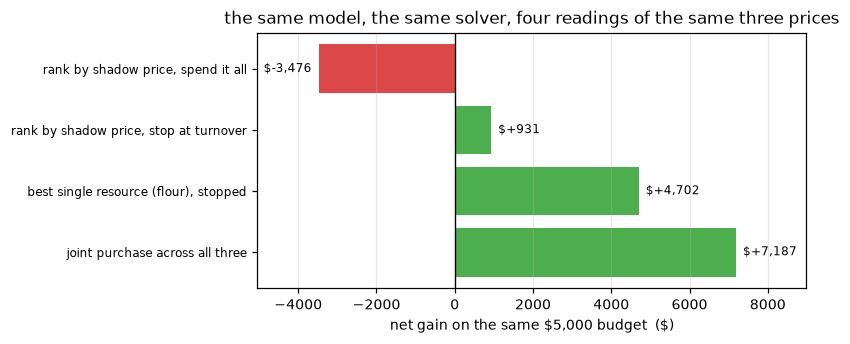

In [25]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
labels = [p[0] for p in plans]
vals   = [net(p[1]) for p in plans]
cols   = ["C3" if v < 0 else "C2" for v in vals]
ax.barh(range(len(vals)), vals, color=cols, alpha=0.85)
ax.set_yticks(range(len(vals)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.axvline(0.0, color="k", lw=0.9)
for k, v in enumerate(vals):
    ax.text(v + (180 if v > 0 else -180), k, f"${v:+,.0f}",
            va="center", ha="left" if v > 0 else "right", fontsize=8)
ax.set_xlim(min(vals) * 1.45, max(vals) * 1.25)
ax.set_xlabel(r"net gain on the same \$5,000 budget  (\$)")
ax.set_title("the same model, the same solver, four readings of the same three prices")
ax.grid(axis="y", visible=False)
fig.tight_layout()

## Summary

* **A shadow price is a derivative, and its range of validity is a separate
  number that no solver prints.** Here the three prices were `$18.00`, `$11.00` and
  `$6.00` and the ranges over which they held were 84.7, 348.3 and 1,277.1 units
  — a factor of fifteen, in the reverse order. Ranked by realized cash the
  resources came out **exactly opposite** to their shadow-price ranking, and the
  top-ranked plan lost `$3,476` on a budget that was worth `$7,187`.

* **The range costs nothing.** `solution_report` runs a ratio test against the
  held KKT factorization, so the current price and the distance to its expiry
  come out of the same single solve. Past the breakpoint the basis is different
  and the held factor cannot speak for it, so each further step of the staircase
  costs exactly one solve — three complete marginal-value schedules over the
  whole `$5,000` took **11 solves**, verified against 117 re-solved prices per resource.

* **High shadow prices tend to be short-lived.** A large multiplier means a
  tightly binding row, which means small changes in $b$ reshuffle the plan
  quickly, which is the condition for the price to move. Both the LP and the
  smooth model put oven time first by price and last by usable range. Ranking
  candidates by a marginal value, without its range, is biased toward exactly
  the wrong ones.

* **Marginal values do not compose.** Each staircase holds the other capacities
  fixed, and the resources are complements: oven time is worth `$18.00/hr` for
  84.7 hours *given the flour on hand*, and for 130 hours if you buy 1,000 kg
  more, because what ends the range is the cake recipe running out and cakes are
  made of flour. The joint optimum duly bought 155.7 oven-hours, nearly twice
  past oven's own measured turnover. The staircase is a large improvement over
  the shadow price and it is still a partial derivative; the last `$2,485` needed
  the joint solve.

* **The free range is a *primal* ratio test, and an active set has two ways to
  change.** `solution_report` reports a coordinate reaching a bound; it is
  silent about an active row that *releases*. On the smooth model that made the
  reported range 21% too long. The remedy is in the same object: `column(pin)`
  carries $\mathrm d\lambda_k/\mathrm db_i$ for **every** row, so a dual ratio
  test over the rows being driven toward zero runs alongside the primal one at
  no extra cost.

* **A refusal is a result.** `mult_entry` gates an inequality's multiplier
  sensitivity on the row being strictly active (gh#910), and on the LP it
  refuses: with no Hessian the reduced curvature is zero and the activity regime
  cannot be measured. That is right. For an LP $\mathrm d\lambda/\mathrm db$ is
  zero within a segment and undefined at every breakpoint, so the staircase — not
  a derivative — is the answer to ask for. The row that did answer, on
  $-4\times10^{-6}$ of rounding noise, is the one not to trust.

Related: [`04_sensitivity.ipynb`](04_sensitivity.ipynb) for the parametric step
itself, [`25_pyomo_sensitivity.ipynb`](25_pyomo_sensitivity.ipynb) and
[`32_wrt_blocks_and_retain_kkt.ipynb`](32_wrt_blocks_and_retain_kkt.ipynb) for
the same machinery from Pyomo,
[`36_active_set_parametric_sensitivity.ipynb`](36_active_set_parametric_sensitivity.ipynb)
for active-set changes along a closed-loop trajectory, and
[`39_design_under_kinetic_uncertainty.ipynb`](39_design_under_kinetic_uncertainty.ipynb)
for the complementary question — an error bar on a shadow price from uncertainty
in the model parameters rather than a range in the right-hand side. The layer
driven here is documented in
[`docs/src/sensitivity.md`](../../docs/src/sensitivity.md).